In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import zipfile
import os

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("olist_data")

In [3]:
import os

os.listdir("olist_data")

['product_category_name_translation.csv',
 'olist_customers_dataset.csv',
 'olist_products_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_sellers_dataset.csv']

In [4]:
orders = pd.read_csv(
    "olist_data/olist_orders_dataset.csv"
)

reviews = pd.read_csv(
    "olist_data/olist_order_reviews_dataset.csv"
)

customers = pd.read_csv(
    "olist_data/olist_customers_dataset.csv"
)

order_items = pd.read_csv(
    "olist_data/olist_order_items_dataset.csv"
)

products = pd.read_csv(
    "olist_data/olist_products_dataset.csv"
)

In [5]:
orders.shape

(99441, 8)

In [6]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [7]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [8]:
orders.describe(include='all').T

,count,unique,top,freq
order_id,99441,99441,66dea50a8b16d9b4dee7af250b4be1a5,1
customer_id,99441,99441,edb027a75a1449115f6b43211ae02a24,1
order_status,99441,8,delivered,96478
order_purchase_timestamp,99441,98875,2018-08-02 12:06:07,3
order_approved_at,99281,90733,2018-02-27 04:31:10,9
order_delivered_carrier_date,97658,81018,2018-05-09 15:48:00,47
order_delivered_customer_date,96476,95664,2018-05-14 20:02:44,3
order_estimated_delivery_date,99441,459,2017-12-20 00:00:00,522


In [9]:
# Cek jumlah missing values
missing_orders = pd.DataFrame({
    'missing_count': orders.isnull().sum(),
    'missing_percentage': orders.isnull().mean() * 100
})

missing_orders

,missing_count,missing_percentage
order_id,0,0.000000
customer_id,0,0.000000
order_status,0,0.000000
order_purchase_timestamp,0,0.000000
order_approved_at,160,0.160899
order_delivered_carrier_date,1783,1.793023
order_delivered_customer_date,2965,2.981668
order_estimated_delivery_date,0,0.000000


In [10]:
orders['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [11]:
orders['order_id'].duplicated().sum()

np.int64(0)

In [12]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [13]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [14]:
print("Tanggal order paling awal :", orders['order_purchase_timestamp'].min())
print("Tanggal order paling akhir:", orders['order_purchase_timestamp'].max())

Tanggal order paling awal : 2016-09-04 21:15:19
Tanggal order paling akhir: 2018-10-17 17:30:18


In [15]:
delivered_orders = orders[
    orders['order_status'] == 'delivered'
].copy()

print("Jumlah delivered orders:", len(delivered_orders))

Jumlah delivered orders: 96478


In [16]:
delivered_orders['order_delivered_customer_date'].isnull().sum()

np.int64(8)

In [17]:
delivered_orders[
    delivered_orders['order_delivered_customer_date'].isnull()
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaT,2018-07-30
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaT,2018-07-30
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaT,2018-07-24
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,NaT,2017-06-23
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaT,2018-06-26
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaT,2018-07-19


In [18]:
delivery_analysis = delivered_orders[
    delivered_orders['order_delivered_customer_date'].notna()
].copy()

print("Jumlah order untuk analisis delivery:", len(delivery_analysis))

Jumlah order untuk analisis delivery: 96470


In [21]:
delivery_analysis['delivery_delay_days'] = (
    delivery_analysis['order_delivered_customer_date']
    - delivery_analysis['order_estimated_delivery_date']
).dt.total_seconds() / (24 * 60 * 60)

In [22]:
delivery_analysis['delivery_delay_days'].describe()

,delivery_delay_days
count,96470.000000
mean,-11.178126
std,10.184354
min,-146.016123
25%,-16.244065
50%,-11.948102
75%,-6.389815
max,188.975081


In [23]:
delivery_analysis[
    ['order_id',
     'order_purchase_timestamp',
     'order_delivered_customer_date',
     'order_estimated_delivery_date',
     'delivery_delay_days']
].sort_values(
    'delivery_delay_days',
    ascending=False
).head(10)

,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days
55619,1b3190b2dfa9d789e1f14c05b647a14a,2018-02-23 14:57:35,2018-09-19 23:24:07,2018-03-15,188.975081
19590,ca07593549f1816d26a572e06dc1eab6,2017-02-21 23:31:27,2017-09-19 14:36:39,2017-03-22,181.608785
11399,47b40429ed8cce3aee9199792275433f,2018-01-03 09:44:01,2018-07-13 20:51:31,2018-01-19,175.869109
81401,2fe324febf907e3ea3f2aa9650869fa5,2017-03-13 20:17:10,2017-09-19 17:00:07,2017-04-05,167.708414
89130,285ab9426d6982034523a855f55a885e,2017-03-08 22:47:40,2017-09-19 14:00:04,2017-04-06,166.583380
61610,440d0d17af552815d15a9e41abe49359,2017-03-07 23:59:51,2017-09-19 15:12:50,2017-04-07,165.633912
68769,c27815f7e3dd0b926b58552628481575,2017-03-15 23:23:17,2017-09-19 17:14:25,2017-04-10,162.718345
40847,d24e8541128cea179a11a65176e0a96f,2017-06-12 13:14:11,2017-12-04 18:36:29,2017-06-26,161.775336
38509,0f4519c5f1c541ddec9f21b3bddd533a,2017-03-09 13:26:57,2017-09-19 14:38:21,2017-04-11,161.609965
54480,2d7561026d542c8dbd8f0daeadf67a43,2017-03-15 11:24:27,2017-09-19 14:38:18,2017-04-13,159.609931


In [24]:
delivery_analysis[
    delivery_analysis['order_delivered_customer_date'].dt.date ==
    pd.to_datetime('2017-09-19').date()
].shape

(282, 9)

In [25]:
delivery_analysis['order_delivered_customer_date'].dt.date.value_counts().head(10)

,count
order_delivered_customer_date,
2018-08-27,446
2018-08-13,442
2018-05-14,434
2018-05-21,431
2018-05-18,425
2018-04-11,413
2017-12-11,412
2018-07-03,410
2018-05-03,409


In [26]:
delivery_analysis[
    delivery_analysis['order_delivered_customer_date'].dt.date ==
    pd.to_datetime('2017-09-19').date()
]['delivery_delay_days'].describe()

,delivery_delay_days
count,282.000000
mean,4.503380
std,41.505385
min,-29.254225
25%,-13.181212
50%,-8.226539
75%,-5.157911
max,181.608785


In [27]:
delivery_analysis[
    delivery_analysis['order_delivered_customer_date'].dt.date ==
    pd.to_datetime('2017-09-19').date()
][[
    'order_id',
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'delivery_delay_days'
]].sort_values(
    'delivery_delay_days',
    ascending=False
).head(10)

,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days
19590,ca07593549f1816d26a572e06dc1eab6,2017-02-21 23:31:27,2017-09-19 14:36:39,2017-03-22,181.608785
81401,2fe324febf907e3ea3f2aa9650869fa5,2017-03-13 20:17:10,2017-09-19 17:00:07,2017-04-05,167.708414
89130,285ab9426d6982034523a855f55a885e,2017-03-08 22:47:40,2017-09-19 14:00:04,2017-04-06,166.583380
61610,440d0d17af552815d15a9e41abe49359,2017-03-07 23:59:51,2017-09-19 15:12:50,2017-04-07,165.633912
68769,c27815f7e3dd0b926b58552628481575,2017-03-15 23:23:17,2017-09-19 17:14:25,2017-04-10,162.718345
38509,0f4519c5f1c541ddec9f21b3bddd533a,2017-03-09 13:26:57,2017-09-19 14:38:21,2017-04-11,161.609965
54480,2d7561026d542c8dbd8f0daeadf67a43,2017-03-15 11:24:27,2017-09-19 14:38:18,2017-04-13,159.609931
70307,2fb597c2f772eca01b1f5c561bf6cc7b,2017-03-08 18:09:02,2017-09-19 14:33:17,2017-04-17,155.606447
31228,dfe5f68118c2576143240b8d78e5940a,2017-03-17 12:32:22,2017-09-19 18:13:19,2017-04-19,153.759248
62286,437222e3fd1b07396f1d9ba8c15fba59,2017-03-16 11:36:00,2017-09-19 16:28:58,2017-04-28,144.686782


In [28]:
delivery_analysis[
    delivery_analysis['order_delivered_customer_date'].dt.date ==
    pd.to_datetime('2017-09-19').date()
][[
    'order_id',
    'order_purchase_timestamp',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'delivery_delay_days'
]].sort_values(
    'delivery_delay_days',
    ascending=False
).head(10)

,order_id,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days
19590,ca07593549f1816d26a572e06dc1eab6,2017-02-21 23:31:27,2017-03-08 13:47:46,2017-09-19 14:36:39,2017-03-22,181.608785
81401,2fe324febf907e3ea3f2aa9650869fa5,2017-03-13 20:17:10,2017-03-17 07:23:53,2017-09-19 17:00:07,2017-04-05,167.708414
89130,285ab9426d6982034523a855f55a885e,2017-03-08 22:47:40,2017-03-09 08:53:20,2017-09-19 14:00:04,2017-04-06,166.583380
61610,440d0d17af552815d15a9e41abe49359,2017-03-07 23:59:51,2017-03-15 13:00:08,2017-09-19 15:12:50,2017-04-07,165.633912
68769,c27815f7e3dd0b926b58552628481575,2017-03-15 23:23:17,2017-03-21 14:50:25,2017-09-19 17:14:25,2017-04-10,162.718345
38509,0f4519c5f1c541ddec9f21b3bddd533a,2017-03-09 13:26:57,2017-03-22 05:28:14,2017-09-19 14:38:21,2017-04-11,161.609965
54480,2d7561026d542c8dbd8f0daeadf67a43,2017-03-15 11:24:27,2017-03-16 09:29:16,2017-09-19 14:38:18,2017-04-13,159.609931
70307,2fb597c2f772eca01b1f5c561bf6cc7b,2017-03-08 18:09:02,2017-03-13 08:54:02,2017-09-19 14:33:17,2017-04-17,155.606447
31228,dfe5f68118c2576143240b8d78e5940a,2017-03-17 12:32:22,2017-03-21 18:28:04,2017-09-19 18:13:19,2017-04-19,153.759248
62286,437222e3fd1b07396f1d9ba8c15fba59,2017-03-16 11:36:00,2017-03-21 08:22:43,2017-09-19 16:28:58,2017-04-28,144.686782


In [29]:
(delivery_analysis['delivery_delay_days'] > 30).sum()

np.int64(360)

In [31]:
delivery_analysis['delivery_status'] = np.select(
    [
        delivery_analysis['delivery_delay_days'] < 0,
        delivery_analysis['delivery_delay_days'] == 0,
        delivery_analysis['delivery_delay_days'] > 0
    ],
    [
        'Early',
        'On Time',
        'Late'
    ],
    default='Unknown'
)

delivery_analysis['delivery_status'].value_counts()

,count
delivery_status,
Early,88644
Late,7826


In [32]:
late_delivery_rate = (
    (delivery_analysis['delivery_status'] == 'Late').sum()
    / len(delivery_analysis)
) * 100

print(f"Late Delivery Rate: {late_delivery_rate:.2f}%")

Late Delivery Rate: 8.11%


In [33]:
reviews = pd.read_csv(
    "olist_data/olist_order_reviews_dataset.csv"
)
reviews.shape

(99224, 7)

In [34]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [35]:
reviews['review_score'].value_counts().sort_index()

,count
review_score,
1,11424
2,3151
3,8179
4,19142
5,57328


In [36]:
delivery_reviews = delivery_analysis.merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='inner'
)

print("Jumlah order setelah digabung:", len(delivery_reviews))

Jumlah order setelah digabung: 96353


In [37]:
delivery_reviews.groupby('delivery_status')['review_score'].agg(
    ['count', 'mean']
).round(2)

,count,mean
delivery_status,,
Early,88653,4.29
Late,7700,2.57


In [38]:
pd.crosstab(
    delivery_reviews['delivery_status'],
    delivery_reviews['review_score'],
    normalize='index'
).mul(100).round(2)

review_score,1,2,3,4,5
delivery_status,,,,,
Early,6.60,2.63,7.99,20.34,62.43
Late,46.16,7.87,11.36,12.39,22.22


In [39]:
products = pd.read_csv(
    "olist_data/olist_products_dataset.csv"
)
products.shape

(32951, 9)

In [40]:
order_items = pd.read_csv(
    "olist_data/olist_order_items_dataset.csv"
)
order_items.shape

(112650, 7)

In [41]:
order_products = order_items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

order_products.shape

(112650, 8)

In [42]:
delivery_category = delivery_reviews.merge(
    order_products[['order_id', 'product_category_name']],
    on='order_id',
    how='left'
)

print("Jumlah baris:", len(delivery_category))

Jumlah baris: 110005


In [43]:
delivery_category = delivery_category.drop_duplicates(
    subset=['order_id', 'product_category_name']
).copy()

print("Jumlah baris setelah deduplikasi:", len(delivery_category))

Jumlah baris setelah deduplikasi: 96616


In [44]:
delivery_category['product_category_name'].isna().sum()

np.int64(1382)

In [45]:
delivery_category_clean = delivery_category[
    delivery_category['product_category_name'].notna()
].copy()

print("Sebelum:", len(delivery_category))
print("Sesudah:", len(delivery_category_clean))

Sebelum: 96616
Sesudah: 95234


In [46]:
category_performance = (
    delivery_category_clean
    .groupby('product_category_name')
    .agg(
        total_orders=('order_id', 'nunique'),
        late_orders=('delivery_status', lambda x: (x == 'Late').sum()),
        avg_review=('review_score', 'mean')
    )
)

category_performance['late_rate'] = (
    category_performance['late_orders']
    / category_performance['total_orders']
) * 100

category_performance = category_performance.sort_values(
    'late_rate',
    ascending=False
)

category_performance.head(10).round(2)

,total_orders,late_orders,avg_review,late_rate
product_category_name,,,,
casa_conforto_2,23,4,3.83,17.39
moveis_colchao_e_estofado,37,5,3.89,13.51
fashion_underwear_e_moda_praia,116,15,4.01,12.93
audio,345,44,3.84,12.75
livros_tecnicos,255,28,4.43,10.98
casa_conforto,390,41,3.89,10.51
alimentos,437,43,4.33,9.84
eletronicos,2498,245,4.12,9.81
construcao_ferramentas_iluminacao,239,22,4.15,9.21


In [47]:
category_performance[
    category_performance['total_orders'] >= 100
].sort_values(
    'late_rate',
    ascending=False
).head(10).round(2)

,total_orders,late_orders,avg_review,late_rate
product_category_name,,,,
fashion_underwear_e_moda_praia,116,15,4.01,12.93
audio,345,44,3.84,12.75
livros_tecnicos,255,28,4.43,10.98
casa_conforto,390,41,3.89,10.51
alimentos,437,43,4.33,9.84
eletronicos,2498,245,4.12,9.81
construcao_ferramentas_iluminacao,239,22,4.15,9.21
bebes,2787,251,4.10,9.01
moveis_escritorio,1244,112,3.64,9.00


In [48]:
category_performance[
    category_performance['total_orders'] >= 100
].sort_values(
    'avg_review',
    ascending=True
).head(10).round(2)

,total_orders,late_orders,avg_review,late_rate
product_category_name,,,,
moveis_escritorio,1244,112,3.64,9.00
fashion_roupa_masculina,105,4,3.82,3.81
audio,345,44,3.84,12.75
casa_conforto,390,41,3.89,10.51
telefonia_fixa,209,10,3.97,4.78
construcao_ferramentas_seguranca,158,7,3.97,4.43
casa_construcao,481,39,3.99,8.11
cama_mesa_banho,9177,788,4.00,8.59
fashion_underwear_e_moda_praia,116,15,4.01,12.93


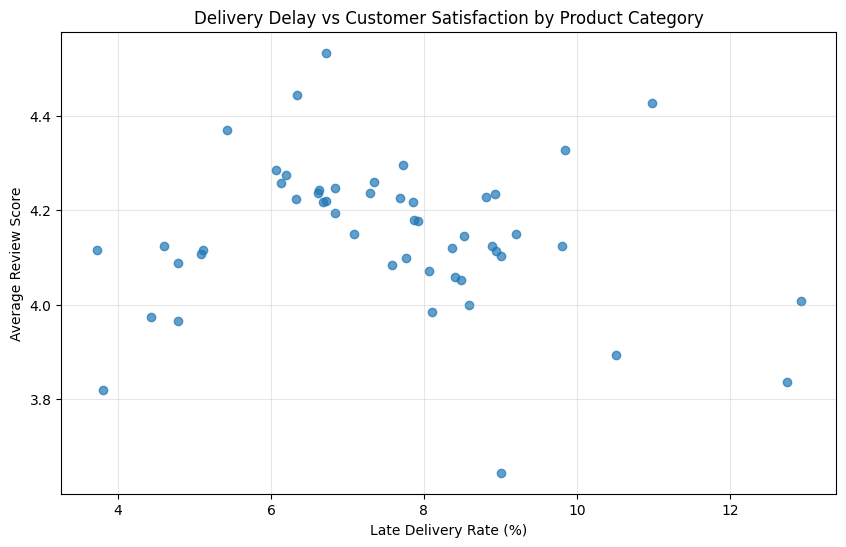

In [49]:
import matplotlib.pyplot as plt

plot_data = category_performance[
    category_performance['total_orders'] >= 100
].copy()

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_data['late_rate'],
    plot_data['avg_review'],
    alpha=0.7
)

plt.xlabel('Late Delivery Rate (%)')
plt.ylabel('Average Review Score')
plt.title('Delivery Delay vs Customer Satisfaction by Product Category')

plt.grid(alpha=0.3)
plt.show()

In [50]:
correlation = plot_data['late_rate'].corr(
    plot_data['avg_review']
)

print(f"Correlation: {correlation:.2f}")

Correlation: -0.14


In [51]:
delivery_reviews['low_rating'] = (
    delivery_reviews['review_score'] <= 2
)

low_rating_rate = (
    delivery_reviews
    .groupby('delivery_status')['low_rating']
    .mean()
    .mul(100)
    .round(2)
)

low_rating_rate

,low_rating
delivery_status,
Early,9.23
Late,54.03


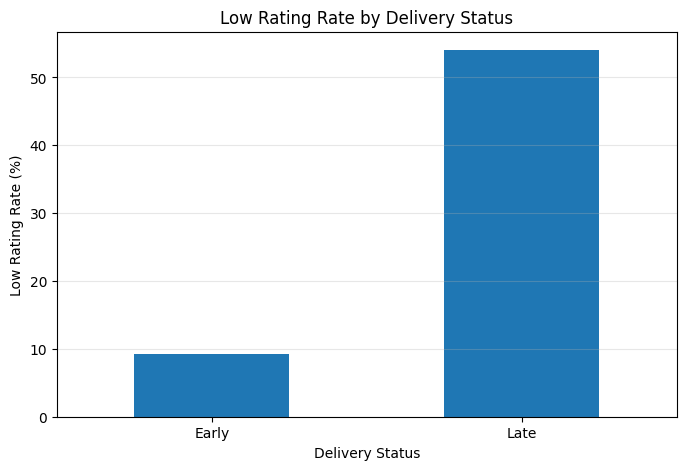

In [52]:
low_rating_rate.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Low Rating Rate by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Low Rating Rate (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

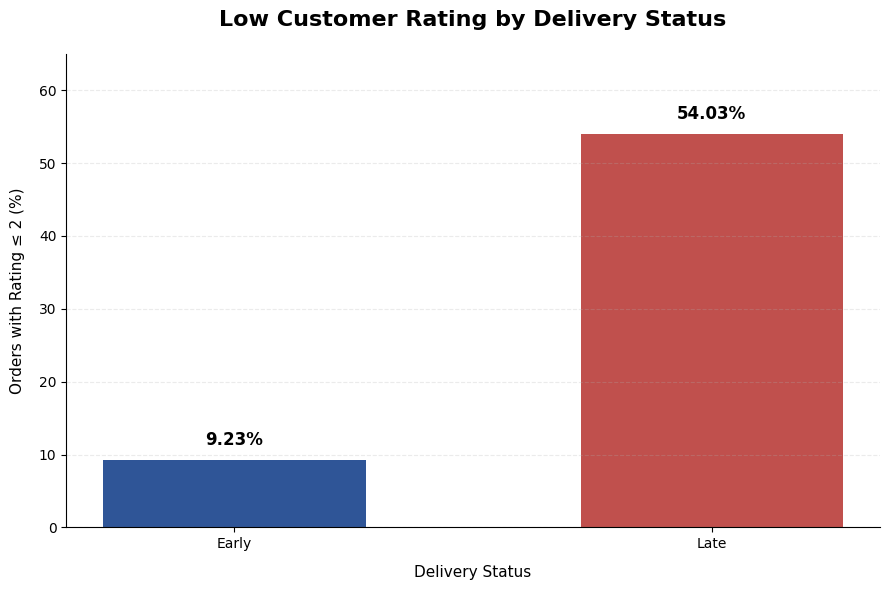

In [53]:
import matplotlib.pyplot as plt

# Data
statuses = low_rating_rate.index
values = low_rating_rate.values

# Warna
colors = ['#2F5597', '#C0504D']

# Figure
fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    statuses,
    values,
    color=colors,
    width=0.55
)

# Judul
ax.set_title(
    'Low Customer Rating by Delivery Status',
    fontsize=16,
    fontweight='bold',
    pad=20
)

# Label
ax.set_xlabel(
    'Delivery Status',
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    'Orders with Rating ≤ 2 (%)',
    fontsize=11,
    labelpad=10
)

# Batas Y
ax.set_ylim(0, 65)

# Grid
ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.25
)

# Hilangkan garis atas & kanan
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Angka di atas bar
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1.5,
        f'{value:.2f}%',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

# Tampilan tick
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()